<a href="https://colab.research.google.com/github/divyasuresh1450-ai/Python-For-Data-Science-/blob/main/practical_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practical no:09

Name:Divya Suresh Gaikwad, Class-SY-A,Roll no:64

Aim:- Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving aistudent.csv to aistudent.csv


In [ ]:
import pandas as pd

df = pd.read_csv('aistudent.csv')
print(df.head())
print(df.info())

   Student_ID  Age  Gender Education_Level       City AI_Tool_Used  \
0           1   15  Female         College  Hyderabad      Copilot   
1           2   21  Female      University    Chennai      Copilot   
2           3   22    Male      University  Bangalore       Gemini   
3           4   22    Male         College  Hyderabad      ChatGPT   
4           5   22    Male         College  Hyderabad       Gemini   

   Daily_Usage_Hours   Purpose Impact_on_Grades Satisfaction_Level  
0                1.1  Learning   Slight Decline             Medium  
1                1.7    Coding   Slight Decline               High  
2                1.5  Learning         Improved                Low  
3                3.8  Research         Improved                Low  
4                5.2    Coding   Slight Decline                Low  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------

In [ ]:
# Check missing values
print(df.isnull().sum())

# Fill numeric columns with mean
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Daily_Usage_Hours'].fillna(df['Daily_Usage_Hours'].mean(), inplace=True)

# Fill categorical columns with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)

print("Missing values cleaned!")

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64
Missing values cleaned!


/tmp/ipykernel_10734/4281357786.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_10734/4281357786.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

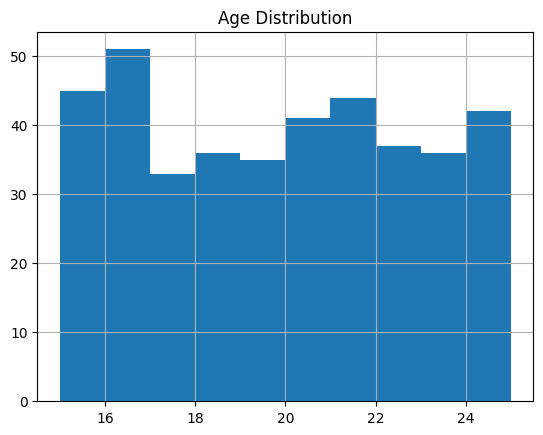

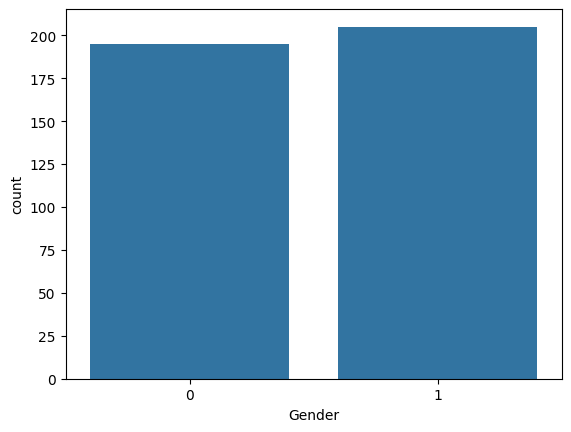

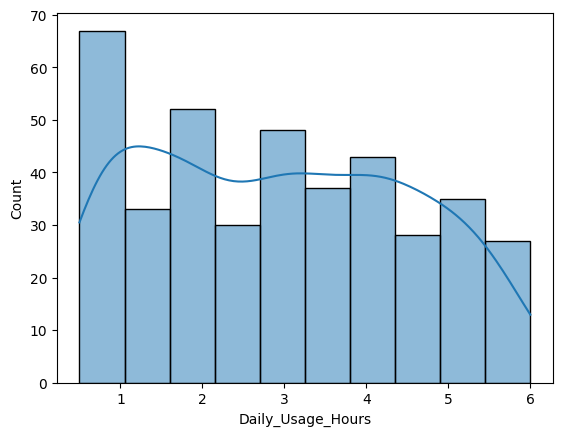

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

# Countplot
sns.countplot(x='Gender', data=df)
plt.show()

# Usage hours distribution
sns.histplot(df['Daily_Usage_Hours'], kde=True)
plt.show()

In [ ]:
print(df.describe())

print("Average Usage:", df['Daily_Usage_Hours'].mean())
print("Max Age:", df['Age'].max())

       Student_ID         Age  Daily_Usage_Hours
count  400.000000  400.000000         400.000000
mean   125.500000   19.425000           2.933750
std     87.906592    2.991948           1.589939
min      1.000000   15.000000           0.500000
25%     50.750000   17.000000           1.575000
50%    100.500000   19.500000           2.900000
75%    200.250000   22.000000           4.200000
max    300.000000   25.000000           6.000000
Average Usage: 2.9337500000000007
Max Age: 25


In [ ]:
print("""
Steps:
1. Load dataset
2. Clean missing values
3. Perform visualization
4. Analyze statistics
5. Prepare for modeling
""")


Steps:
1. Load dataset
2. Clean missing values
3. Perform visualization
4. Analyze statistics
5. Prepare for modeling



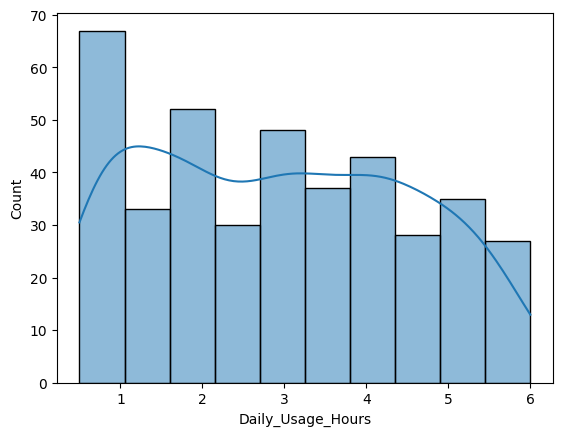

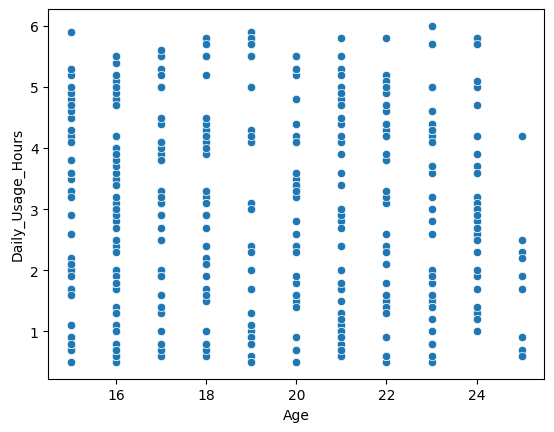

                        Age  Daily_Usage_Hours
Age                1.000000           0.000823
Daily_Usage_Hours  0.000823           1.000000


In [ ]:
# Univariate
sns.histplot(df['Daily_Usage_Hours'], kde=True)
plt.show()

# Bivariate
sns.scatterplot(x='Age', y='Daily_Usage_Hours', data=df)
plt.show()

# Correlation (only numeric)
print(df[['Age', 'Daily_Usage_Hours']].corr())

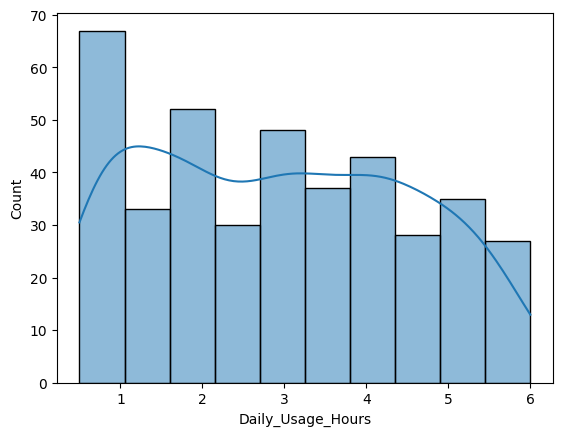

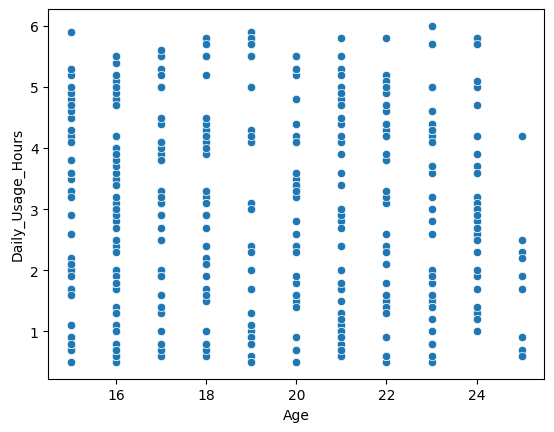

                        Age  Daily_Usage_Hours
Age                1.000000           0.000823
Daily_Usage_Hours  0.000823           1.000000


In [ ]:
# Univariate
sns.histplot(df['Daily_Usage_Hours'], kde=True)
plt.show()

# Bivariate
sns.scatterplot(x='Age', y='Daily_Usage_Hours', data=df)
plt.show()

# Correlation (only numeric)
print(df[['Age', 'Daily_Usage_Hours']].corr())

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['City'] = le.fit_transform(df['City'])
df['AI_Tool_Used'] = le.fit_transform(df['AI_Tool_Used'])
df['Purpose'] = le.fit_transform(df['Purpose'])
df['Impact_on_Grades'] = le.fit_transform(df['Impact_on_Grades'])
df['Satisfaction_Level'] = le.fit_transform(df['Satisfaction_Level'])

print(df.head())

   Student_ID  Age  Gender  Education_Level  City  AI_Tool_Used  \
0           1   15       0                0     5             1   
1           2   21       0                2     2             1   
2           3   22       1                2     1             2   
3           4   22       1                0     5             0   
4           5   22       1                0     5             2   

   Daily_Usage_Hours  Purpose  Impact_on_Grades  Satisfaction_Level  
0                1.1        2                 2                   2  
1                1.7        0                 2                   0  
2                1.5        2                 0                   1  
3                3.8        3                 0                   1  
4                5.2        0                 2                   1  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(['Daily_Usage_Hours'], axis=1)
y = df['Daily_Usage_Hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2.7074964208506707
R2 Score: -0.03964785203023746


In [ ]:
def load_data(path):
    return pd.read_csv(path)

def clean_data(df):
    df.fillna(df.mean(numeric_only=True), inplace=True)
    return df

def encode_data(df):
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col])
    return df

def train_model(X, y):
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X, y)
    return model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "R2:", r2_score(y_test, pred))

Linear Regression R2: -0.03964785203023746
Random Forest R2: -0.11748539283237203


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__fit_intercept': [True, False]
}

grid = GridSearchCV(pipeline, params, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__fit_intercept': True}


In [ ]:
print("""
Model Interpretation:
- Higher R2 score = better performance
- Low MSE = accurate predictions
- Compare models to select best one
""")


Model Interpretation:
- Higher R2 score = better performance
- Low MSE = accurate predictions
- Compare models to select best one



1. What is a Data Science Pipeline? Explain its key stages with examples.

A Data Science pipeline is a structured sequence of steps used to process raw data and convert it into useful insights or predictions.
Key Stages:
Data Collection:
Gathering data from sources like CSV files, databases, APIs
Example: Loading aistudent.csv

Data Cleaning:
Handling missing values, removing duplicates, fixing errors
Example: Filling missing age values with mean
Exploratory Data Analysis (EDA)

Understanding patterns using graphs and statistics
Example: Histogram of usage hours
Feature Engineering

Creating new meaningful features
Example: Converting age into age groups

Model Building:
Training machine learning models
Example: Linear Regression to predict usage hours

Model Evaluation:
Checking performance using metrics
Example: R² score, MSE

Deployment (optional)
Using model in real applications
Example: Prediction system in a website




2. What is Exploratory Data Analysis (EDA)?

EDA (Exploratory Data Analysis) is the process of analyzing and summarizing data using statistics and visualizations to understand its structure and patterns.
Types of Analysis:
 Univariate Analysis (Single Variable):
Focuses on one variable at a time
Tools: Mean, median, histogram
it helps to:
Understand distribution,Detect outliers,
Identify skewness
Example: Distribution of student age

Bivariate Analysis (Two Variables)
Studies relationship between two variables
Tools: Scatter plot, correlation
Helps to:Identify relationships,Detect trends
Check dependency
Example: Age vs Daily Usage Hours

3.Differentiate between Label Encoding and OneHot Encoding. When should each be used?


| Feature      | Label Encoding        | One-Hot Encoding         |
| ------------ | --------------------- | ------------------------ |
| Method       | Assign numbers        | Create binary columns    |
| Example      | Male=0, Female=1      | Male=[1,0], Female=[0,1] |
| Type of Data | Ordinal               | Nominal                  |
| Advantage    | Simple, less memory   | No false ordering        |
| Disadvantage | Creates false ranking | Increases columns        |

When to Use:

Label Encoding: When data has order
(e.g., Low, Medium, High),

One-Hot Encoding: When no order exists
(e.g., City, Gender)

4.Why is feature scaling required? Compare normalization and standardization.


Feature scaling ensures all variables are on the same scale so that no feature dominates others during model training.

Why Needed:
Improves model accuracy
Helps faster convergence
Important for distance-based models (KNN, SVM)
 Normalization (Min-Max Scaling)
Scales data between 0 and 1

	​


Best for: Data without outliers

 Standardization (Z-score Scaling)
Mean = 0, Standard deviation = 1
Best for: Data with outliers

Comparison:
Feature	Normalization	Standardization
Range	0 to 1	Not fixed
Outliers	Sensitive	Handles better
Use Case	Neural Networks	ML models


5. What is Feature Engineering?

Feature engineering is the process of creating new features from existing data to improve model performance.

Examples:
Age → Age Group
Date → Year, Month
Total marks → Average score

How it Improves Model Performance:
Captures hidden patterns
Makes data more meaningful
Improves accuracy
Helps models learn better relationships

Example:
Instead of raw age, grouping into “Teen”, “Adult” may improve predictions.